In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
#Loading the data
import pandas as pd

df = pd.read_csv("OnlineRetail.csv", encoding='latin1')

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [ ]:
print(df.shape) #Rows and Columns

(541909, 8)


In [7]:
#information o datasets
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [9]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

In [10]:
# Remove cancelled orders (InvoiceNo starting with C)
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [11]:
# Remove negative or zero quantities
df = df[df['Quantity'] > 0]

In [12]:

# Remove negative or zero prices
df = df[df['UnitPrice'] > 0]

In [13]:

print(df.shape)

(397884, 8)


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    397884 non-null  object 
 1   StockCode    397884 non-null  object 
 2   Description  397884 non-null  object 
 3   Quantity     397884 non-null  int64  
 4   InvoiceDate  397884 non-null  object 
 5   UnitPrice    397884 non-null  float64
 6   CustomerID   397884 non-null  float64
 7   Country      397884 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 27.3+ MB


In [15]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [16]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(df['InvoiceDate'].dtype)

datetime64[ns]


In [17]:
import datetime as dt

snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalAmount': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [18]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [19]:
rfm['R_Score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])

rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
CustomerID,,,,,,
12346.0,326,1,77183.60,1,1,4
12347.0,2,7,4310.00,4,4,4
12348.0,75,4,1797.24,2,3,4
12349.0,19,1,1757.55,3,1,4
12350.0,310,1,334.40,1,1,2


In [20]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [21]:
def segment_customer(row):
    if row['RFM_Score'] == '444':
        return 'Champions'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return 'Loyal Customers'
    elif row['R_Score'] >= 3:
        return 'Potential Loyalists'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost Customers'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

rfm.head()

,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
CustomerID,,,,,,,,
12346.0,326,1,77183.60,1,1,4,114,Lost Customers
12347.0,2,7,4310.00,4,4,4,444,Champions
12348.0,75,4,1797.24,2,3,4,234,At Risk
12349.0,19,1,1757.55,3,1,4,314,Potential Loyalists
12350.0,310,1,334.40,1,1,2,112,Lost Customers


In [22]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

Segment
Lost Customers         1504
Loyal Customers        1033
Potential Loyalists     665
At Risk                 646
Champions               490
Name: count, dtype: int64


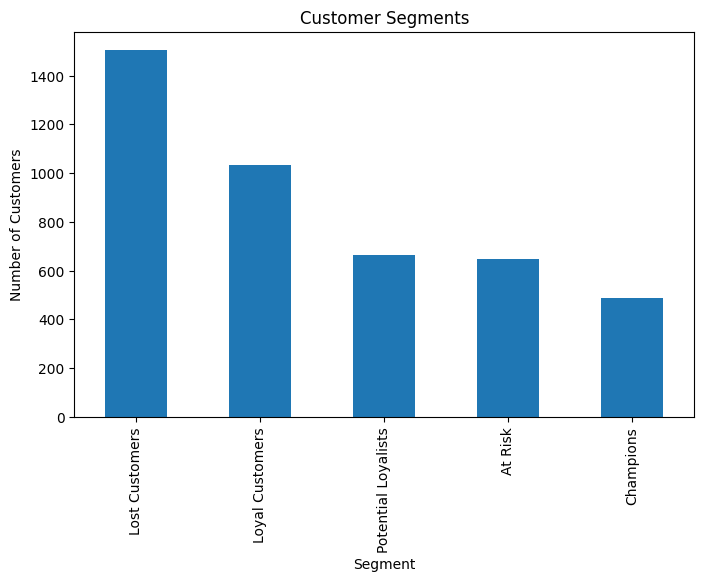

In [23]:
import matplotlib.pyplot as plt

segment_counts.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Customer Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')
plt.show()

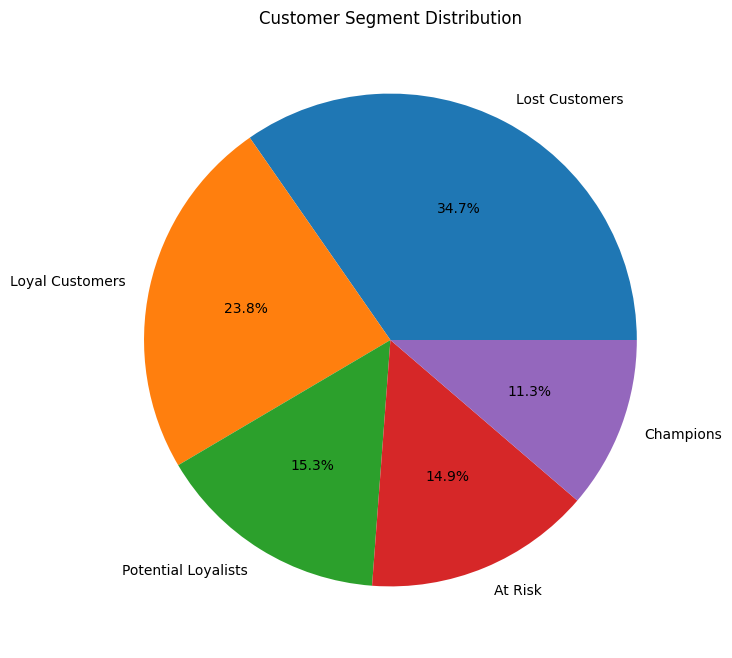

In [24]:
plt.figure(figsize=(8,8))

segment_counts.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.ylabel('')
plt.title('Customer Segment Distribution')
plt.show()

In [25]:
top_customers = rfm.sort_values(
    by='Monetary',
    ascending=False
).head(10)

print(top_customers[['Monetary']])

             Monetary
CustomerID           
14646.0     280206.02
18102.0     259657.30
17450.0     194550.79
16446.0     168472.50
14911.0     143825.06
12415.0     124914.53
14156.0     117379.63
17511.0      91062.38
16029.0      81024.84
12346.0      77183.60


In [26]:
rfm.to_csv('Customer_Segmentation_RFM.csv')

In [27]:
segment_summary = rfm.groupby('Segment').agg({
    'Recency':'mean',
    'Frequency':'mean',
    'Monetary':'mean'
})

print(segment_summary)

                        Recency  Frequency     Monetary
Segment                                                
At Risk              119.198142   4.171827  1611.350915
Champions              7.434694  15.514286  9050.497408
Lost Customers       186.571144   1.251330   510.071039
Loyal Customers       22.636012   5.217812  2097.416671
Potential Loyalists   25.251128   1.448120   754.816872
